# 06 — Generalization Eval on CityLearn 2.6 with `src.eval` · Google Colab

**Phase 2 / Month 2** · MSc Thesis — ECLIPSE project  
Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

## What's different from v1

- v1 ran on CityLearn 2.5 (Colab's default `pip install CityLearn`) and used the
  legacy `env.evaluate()` long-format DataFrame, which we had to pivot by hand.
- v2 pins **CityLearn 2.6.0b2** (PyPI pre-release) so we can use
  `env.evaluate_v2()` — the same API the rest of the codebase targets — and
  call our standardised `src.eval.evaluate / comparison_table /
  generalisation_gap` directly.
- KPIs produced match nb04 / nb05 / nb01 exactly, so v1-of-nb06 numbers and
  v2-of-nb06 numbers are **not** directly comparable — v2's are the canonical
  ones for the thesis.

## What this notebook does

Loads an already-trained LoRA adapter from Drive (default: the nb05 v2 adapter)
and evaluates the SLM across a grid of (season, building subset) windows.
For each config it collects:
* Challenge scores (C, G, R, 1−L, Phase I, Combined) via `src.eval.challenge_score`
* ZNE + self-consumption ratios via `src.eval.zne_metric`
* Action-token distribution (CHARGE / IDLE / DISCHARGE)
* Per-building SoC traces
* Generalisation gap (training-set baseline → unseen-buildings/season delta)


## § 0 — Config
> Edit this cell only.

In [ ]:
import os, sys, subprocess, time, warnings, json, random
import numpy as np

# ── Repo ─────────────────────────────────────────────────────────────────
GITHUB_REPO = "https://github.com/antonisbast/eclipse-thesis.git"
REPO_DIR    = "/content/eclipse-thesis"

# ── Model + adapter ──────────────────────────────────────────────────────
MODEL_ID:     str  = "unsloth/gemma-4-E4B-it"
LOAD_IN_4BIT: bool = True
MAX_SEQ_LEN:  int  = 1024
MAX_NEW_TOKENS:int = 200

# nb05 v3 § 12 copies its adapter to .../sft_adaptersV3/lora_adapter
ADAPTER_PATH = "/content/drive/MyDrive/eclipse-thesis/sft_adaptersV3/lora_adapter"
ADAPTER_TAG  = "v3"   # label that appears in result tables

# ── CityLearn version ────────────────────────────────────────────────────
# 2.6 introduces evaluate_v2(); our src/eval.py depends on it. 2.6.0b2 is
# the latest pre-release that ships the API our codebase targets.
CITYLEARN_VERSION = "2.6.0b2"

# ── Eval grid ────────────────────────────────────────────────────────────
# Dataset starts at Month 7 (July) hour 0. Season midpoints (2-week
# windows, 336 hours): summer ≈ t=1100, autumn ≈ t=3300,
# winter ≈ t=5500, spring ≈ t=7700.
EVAL_LEN = 336    # 2 weeks per rollout

# The SFT'd adapter was trained on 3-bldg slices (TRAINING_BUILDINGS=[0,1,2]
# and HELDOUT_BUILDINGS=[3,4,5]); evaluating on a 6-bldg env would be OOD on
# the prompt shape. Keep every config 3-wide so all rows are in-distribution
# for the action vocabulary the model learnt.
#   summer_train     — in-distribution buildings, summer week
#   summer_heldout   — same dataset, held-out buildings (RQ2: in-dist gen.)
#   summer_unseen_a  — OOD: other 2022-dataset buildings, slice A
#   summer_unseen_b  — OOD: other 2022-dataset buildings, slice B
# Each SLM rollout is ~110 min on L4 at 336 steps. Comment out configs to fit
# the Colab session.
CONFIGS = [
    {"name": "summer_train",    "start": 1100, "buildings": [0, 1, 2]},
    {"name": "summer_heldout",  "start": 1100, "buildings": [3, 4, 5]},
    {"name": "summer_unseen_a", "start": 1100, "buildings": [6, 7, 8]},
    {"name": "summer_unseen_b", "start": 1100, "buildings": [9, 10, 11]},
]

# The generalisation gap (§ 8) is computed between the config whose
# `buildings` exactly matches TRAIN_BUILDINGS and every other config.
TRAIN_BUILDINGS = [0, 1, 2]   # = src.env.TRAINING_BUILDINGS

# ── Misc ─────────────────────────────────────────────────────────────────
HF_TOKEN: str = ""
SEED          = 42

import torch
if torch.cuda.is_available():
    g = torch.cuda.get_device_properties(0)
    print(f"✓ GPU: {g.name}  ({g.total_memory/1e9:.1f} GB VRAM)")
else:
    print("⚠ No GPU — set Runtime → Change runtime type → T4/L4")

n_slm = len(CONFIGS)
est_min = n_slm * EVAL_LEN / 168 * 55  # 55 min per 168-step SLM rollout on L4
print(f"Grid: {n_slm} SLM rollouts × {EVAL_LEN} steps  ≈  {est_min:.0f} min wall time")

## § 1 — Installs (CityLearn 2.6.0b2 pinned)

In [2]:
# CityLearn 2.6 is a pre-release on PyPI — pin the version explicitly.
# --no-deps because CityLearn pulls heavy/legacy deps we don't need at eval
# time (e.g. some EnergyPlus extras). We install the runtime deps explicitly.
!pip install -q numpy gymnasium doe-xstock nrel-pysam
!pip install -q --pre "CityLearn=={CITYLEARN_VERSION}" --no-deps

import citylearn
assert citylearn.__version__.startswith("2.6"), (
    f"Expected CityLearn 2.6.x, got {citylearn.__version__}. "
    f"src.eval depends on evaluate_v2() which only exists in 2.6+."
)
print(f"✓ CityLearn {citylearn.__version__}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 12.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.6/423.6 kB 11.8 MB/s eta 0:00:00
✓ CityLearn 2.6.0b2


In [ ]:
# Unsloth + LoRA inference stack (no TRL training stack needed here).
# IMPORTANT: pip version constraints MUST be quoted — otherwise the shell
# interprets `<` as input-redirection (e.g. `transformers<=5.5.0` would try
# to read from a file literally named `=5.5.0`) and the constraint is dropped.
!pip install -q --upgrade pip
!pip install -q --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps git+https://github.com/unslothai/unsloth-zoo.git
!pip install -q 'transformers<=5.5.0' 'datasets<4.4.0' 'trl<=0.24.0' tyro peft accelerate bitsandbytes sentencepiece torchao cut_cross_entropy hf_transfer msgspec
!pip install -q triton==3.6.0
print("✓ Unsloth + PEFT inference stack installed")

## § 2 — Clone repo + mount Drive

In [7]:
if not os.path.exists(REPO_DIR):
    res = subprocess.run(["git", "clone", GITHUB_REPO, REPO_DIR], capture_output=True, text=True)
    print(res.stdout or res.stderr)
else:
    res = subprocess.run(["git", "-C", REPO_DIR, "pull"], capture_output=True, text=True)
    print("Repo present —", res.stdout.strip() or "up to date")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from google.colab import drive
drive.mount('/content/drive')

assert os.path.isdir(ADAPTER_PATH), (
    f"Adapter not found at {ADAPTER_PATH}.\n"
    f"Inspect candidates:  !ls /content/drive/MyDrive/eclipse-thesis/sft_adaptersV2/"
)
print(f"✓ Adapter found at {ADAPTER_PATH}")

Repo present — Already up to date.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Adapter found at /content/drive/MyDrive/eclipse-thesis/sft_adaptersV2/lora_adapter


## § 3 — Load base Gemma + attach the saved LoRA adapter

In [10]:
from unsloth import FastModel
from peft import PeftModel
import torch, time

torch.cuda.empty_cache()

_t0 = time.time()
model, tokenizer = FastModel.from_pretrained(
    model_name      = MODEL_ID,
    max_seq_length  = MAX_SEQ_LEN,
    dtype           = None,
    load_in_4bit    = LOAD_IN_4BIT,
    full_finetuning = False,
    token           = HF_TOKEN or None,
)
print(f"Base model loaded in {time.time()-_t0:.1f}s")

_t0 = time.time()
model = PeftModel.from_pretrained(model, ADAPTER_PATH)
print(f"LoRA adapter attached in {time.time()-_t0:.1f}s")

FastModel.for_inference(model)
print("✓ Inference path enabled")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.8.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

...

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Base model loaded in 395.8s
LoRA adapter attached in 10.1s
✓ Inference path enabled


## § 4 — `SFTProvider` (identical to nb05 v2 § 7)

In [ ]:
import logging, re
from src.sft import parse_actions, make_sft_prompt

_logger = logging.getLogger("sft_slm")
# Opening-tag-only check — DIFFERENT from src.agent.ACTION_RE (full parser).
_ACTION_TAG_RE = re.compile(r"<action\s+building\s*=\s*\d+\s*>", re.IGNORECASE)
_is_gemma  = "gemma" in MODEL_ID.lower()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

class SFTProvider:
    def __init__(self, model, tokenizer, max_new_tokens: int = 200):
        self.model         = model.eval()
        self.tokenizer     = tokenizer
        self.max_new_tokens= max_new_tokens
        self.label         = f"sft_{ADAPTER_TAG}:{MODEL_ID.split('/')[-1]}"
        self._device       = next(model.parameters()).device

    def complete(self, system: str, user: str, max_tokens=None) -> str:
        max_new = max_tokens or self.max_new_tokens
        if _is_gemma:
            msgs = [{"role": "user", "content": f"{system}\n\n{user}"}]
        else:
            msgs = [{"role": "system", "content": system},
                    {"role": "user",   "content": user}]
        enc = self.tokenizer.apply_chat_template(
            msgs, tokenize=True, add_generation_prompt=True,
            return_tensors="pt", return_dict=True,
        ).to(self._device)
        with torch.no_grad():
            out = self.model.generate(
                **enc,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
            )
        new_tokens = out[0][enc["input_ids"].shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True)

    def step(self, state_text: str, system=None, n_buildings: int = 6,
             max_retries: int = 2, **kw):
        sys_p = system or make_sft_prompt(n_buildings)
        last  = ""
        for _ in range(max_retries):
            last = self.complete(sys_p, f"STATE:\n{state_text}")
            if _ACTION_TAG_RE.search(last):
                return parse_actions(last, n_buildings), last, False
        return [0.0]*n_buildings, last, True


slm = SFTProvider(model, tokenizer, max_new_tokens=MAX_NEW_TOKENS)
print(f"Provider ready: {slm.label}")


## § 5 — Env factory + rollout helpers (using `src/`)

In [ ]:
from citylearn.citylearn import CityLearnEnv
from citylearn.agents.rbc import BasicBatteryRBC
from src.env import (
    make_env, snapshot_state, MERLINReward,
    OBSERVATIONS, ACTIVE_ACTIONS, BUILDINGS,
)
from src.sft import render_state
from src.eval import evaluate, comparison_table, generalisation_gap, EvalResult

warnings.filterwarnings("ignore")
np.random.seed(SEED); random.seed(SEED)

# Use the project-wide src.env.make_env (loads the local schema patched to an
# absolute path) so this notebook evaluates on the SAME dataset/schema that
# nb 04 trained SAC on and nb 05 dumped the SFT JSONL from. The repo was
# cloned in § 2, so `data/citylearn_datasets/citylearn_challenge_2022_phase_all`
# is on disk.
def make_eval_env(start: int, length: int, buildings: list[int]) -> CityLearnEnv:
    return make_env(
        buildings = buildings,
        start     = start,
        end       = start + length - 1,
        reward_fn = "merlin",
    )

_TOK_RE = re.compile(r"<action building=\d+>([A-Z_0-9]+)</action>")

def run_slm_rollout(cfg: dict) -> dict:
    import collections
    buildings = cfg["buildings"]
    n_b       = len(buildings)
    env       = make_eval_env(cfg["start"], EVAL_LEN, buildings)
    env.reset()
    sys_p     = make_sft_prompt(n_b)
    tokens    = collections.Counter()
    n_fb      = 0
    t0        = time.time()
    done, t   = False, 0
    while not done:
        snap = snapshot_state(env)
        acts, raw, fb = slm.step(render_state(snap), system=sys_p, n_buildings=n_b)
        n_fb += int(fb)
        tokens.update(_TOK_RE.findall(raw))
        _, _, term, trunc, _ = env.step([[float(a)] for a in acts])
        done = bool(term or trunc)
        if t % 48 == 0:
            print(f"  [{cfg['name']}] t={t:4d}/{EVAL_LEN}  fb={n_fb}  {time.time()-t0:.0f}s")
        t += 1
    elapsed = time.time() - t0
    print(f"  [{cfg['name']}] done in {elapsed:.0f}s | fallbacks={n_fb}/{t}")
    return {"env": env, "tokens": tokens, "fb": n_fb, "elapsed": elapsed}

def run_rbc_rollout(cfg: dict) -> CityLearnEnv:
    env = make_eval_env(cfg["start"], EVAL_LEN, cfg["buildings"])
    BasicBatteryRBC(env=env).learn(episodes=1)
    return env

def run_noop_rollout(cfg: dict) -> CityLearnEnv:
    env = make_eval_env(cfg["start"], EVAL_LEN, cfg["buildings"])
    env.reset()
    n_b  = len(cfg["buildings"])
    done = False
    while not done:
        _, _, term, trunc, _ = env.step([[0.0] for _ in range(n_b)])
        done = bool(term or trunc)
    return env

print(f"CityLearn {citylearn.__version__}  |  {len(CONFIGS)} configs queued")

## § 6 — Run the grid
Per config: no-op + RBC + SLM. Each rollout is converted to an `EvalResult`
using `src.eval.evaluate(env, label)` so the KPI extraction is identical to
nb04 / nb05's reporting.

In [13]:
import pandas as pd

# Per-config: list of EvalResults (No-Control, RBC, SLM)
per_config_results: dict[str, list[EvalResult]] = {}

for cfg in CONFIGS:
    print(f"\n{'='*60}\n {cfg['name']}  |  start={cfg['start']}  buildings={cfg['buildings']}  steps={EVAL_LEN}\n{'='*60}")

    print("  No-Control …");  env_no  = run_noop_rollout(cfg)
    print("  RBC …");         env_rbc = run_rbc_rollout(cfg)
    print("  SLM …")
    slm_out  = run_slm_rollout(cfg)
    env_slm  = slm_out["env"]

    res_noop = evaluate(env_no,  label=f"NoControl@{cfg['name']}")
    res_rbc  = evaluate(env_rbc, label=f"RBC@{cfg['name']}")
    res_slm  = evaluate(env_slm, label=f"{slm.label}@{cfg['name']}")
    per_config_results[cfg['name']] = [res_noop, res_rbc, res_slm]

    print(f"  action tokens (SLM): {dict(slm_out['tokens'])}")

    cfg["_envs"]    = {"No-Control": env_no, "RBC": env_rbc, "SLM": env_slm}
    cfg["_results"] = {"No-Control": res_noop, "RBC": res_rbc, "SLM": res_slm}
    cfg["_tokens"]  = slm_out["tokens"]
    cfg["_fb"]      = slm_out["fb"]
    cfg["_t_sec"]   = slm_out["elapsed"]

total_slm_min = sum(c['_t_sec'] for c in CONFIGS) / 60
print(f"\n✓ Grid complete. Total SLM wall time: {total_slm_min:.1f} min")

INFO:root:The dataset names DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.6.0b2 GitHub repository and write to /root/.cache/citylearn/v2.6.0b2/dataset_names.json. Next time DataSet.get_dataset_names is called, it will read from cache unless DataSet.clear_cache is run first.



 summer_unseen  |  start=1100  buildings=[6, 7, 8, 9, 10, 11]  steps=336
  No-Control …


INFO:root:The citylearn_challenge_2022_phase_all dataset DNE in cache/local roots. Will download from intelligent-environments-lab/CityLearn/tree/v2.6.0b2 GitHub repository and write to /root/.cache/citylearn/v2.6.0b2/datasets. Next time DataSet.get_dataset('citylearn_challenge_2022_phase_all') is called, it will read from cache unless DataSet.clear_cache is run first.


  RBC …
  SLM …
  [summer_unseen] t=   0/336  fb=0  60s
  [summer_unseen] t=  48/336  fb=0  1085s
  [summer_unseen] t=  96/336  fb=0  2077s
  [summer_unseen] t= 144/336  fb=0  3053s
  [summer_unseen] t= 192/336  fb=0  4047s
  [summer_unseen] t= 240/336  fb=0  5029s
  [summer_unseen] t= 288/336  fb=0  6024s
  [summer_unseen] done in 6977s | fallbacks=0/335
  action tokens (SLM): {'DISCHARGE_20': 1091, 'DISCHARGE_40': 356, 'CHARGE_20': 229, 'IDLE': 187, 'CHARGE_40': 147}

✓ Grid complete. Total SLM wall time: 116.3 min


## § 7 — Challenge & ZNE tables (via `src.eval.comparison_table`)
One Challenge-score table and one ZNE table per config. Indexed by agent
label, columns are the canonical KPIs the rest of the codebase uses.

In [14]:
for cfg in CONFIGS:
    name = cfg['name']
    print(f"\n── {name}  (start={cfg['start']}, buildings={cfg['buildings']}) ──")
    chal_df, zne_df = comparison_table(list(cfg["_results"].values()))
    print("Challenge scores (lower is better):")
    display(chal_df)
    print("ZNE / self-consumption:")
    display(zne_df[["ZNE ratio (solar / import)", "self-consumption ratio"]])


── summer_unseen  (start=1100, buildings=[6, 7, 8, 9, 10, 11]) ──
Challenge scores (lower is better):


,C — cost,G — carbon,R — ramping,1L — load factor,Phase I (C+G)/2,Combined (C+G+D)/3
NoControl@summer_unseen,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
RBC@summer_unseen,0.9455,1.0568,1.0974,0.9273,1.0012,1.0049
sft_v2:gemma-4-E4B-it@summer_unseen,0.8830,0.9113,0.9623,0.9136,0.8972,0.9108


ZNE / self-consumption:


,ZNE ratio (solar / import),self-consumption ratio
NoControl@summer_unseen,1.1634,0.6155
RBC@summer_unseen,1.1741,0.6994
sft_v2:gemma-4-E4B-it@summer_unseen,1.2869,0.7835


## § 7.1 — Cross-config summary (Phase I score per agent per config)

In [15]:
rows = []
for cfg in CONFIGS:
    for policy_lbl, res in cfg['_results'].items():
        rows.append({
            "config":              cfg['name'],
            "policy":              policy_lbl,
            "C  — cost":           res.challenge["C  — cost"],
            "G  — carbon":         res.challenge["G  — carbon"],
            "R  — ramping":        res.challenge["R  — ramping"],
            "1L — load factor":    res.challenge["1L — load factor"],
            "Phase I":             res.challenge["Phase I (C+G)/2"],
            "Combined":            res.challenge["Combined (C+G+D)/3"],
            "ZNE ratio":           res.zne["ZNE ratio (solar / import)"],
            "self-consumption":    res.zne["self-consumption ratio"],
        })

summary_df = pd.DataFrame(rows).set_index(["config", "policy"]).round(4)
print("Cross-config Phase-I + ZNE summary:")
display(summary_df)

# SLM-vs-RBC delta on Phase I — the headline number for each config.
slm_vs_rbc = (
    summary_df.xs("SLM", level="policy")["Phase I"] -
    summary_df.xs("RBC", level="policy")["Phase I"]
).round(4)
print("\nΔ Phase I (SLM − RBC) — negative = SLM beats RBC:")
display(slm_vs_rbc.to_frame("Δ Phase I"))

Cross-config Phase-I + ZNE summary:


C  — cost  G  — carbon  R  — ramping  \
config        policy                                             
summer_unseen No-Control     1.0000       1.0000        1.0000   
              RBC            0.9455       1.0568        1.0974   
              SLM            0.8830       0.9113        0.9623   

                          1L — load factor  Phase I  Combined  ZNE ratio  \
config        policy                                                       
summer_unseen No-Control            1.0000   1.0000    1.0000     1.1634   
              RBC                   0.9273   1.0012    1.0049     1.1741   
              SLM                   0.9136   0.8972    0.9108     1.2869   

                          self-consumption  
config        policy                        
summer_unseen No-Control            0.6155  
              RBC                   0.6994  
              SLM                   0.7835


Δ Phase I (SLM − RBC) — negative = SLM beats RBC:


,Δ Phase I
config,
summer_unseen,-0.104


## § 8 — Generalisation gap (`src.eval.generalisation_gap`)
Pairs a training-buildings config with each non-training config and reports
the gap on Phase I + ZNE. Computed only if your grid contains both kinds.

In [16]:
train_cfg = next(
    (c for c in CONFIGS if set(c["buildings"]) == set(TRAIN_BUILDINGS)),
    None,
)
unseen_cfgs = [c for c in CONFIGS if c is not train_cfg]

if train_cfg is None or not unseen_cfgs:
    print("No matched (train, unseen) pair in CONFIGS — skipping gap.")
    print("To enable, add one config with buildings == TRAIN_BUILDINGS and at")
    print("least one with a different building set.")
else:
    print(f"Train-baseline config: {train_cfg['name']}\n")
    train_slm = train_cfg["_results"]["SLM"]
    for ucfg in unseen_cfgs:
        unseen_slm = ucfg["_results"]["SLM"]
        gap = generalisation_gap(train_slm, unseen_slm)
        print(f"── SLM gap: {train_cfg['name']} → {ucfg['name']} ──")
        display(pd.Series(gap, name="Δ (unseen − train)").round(4).to_frame())

No matched (train, unseen) pair in CONFIGS — skipping gap.
To enable, add one config with buildings == TRAIN_BUILDINGS and at
least one with a different building set.


## § 9 — Action distribution per config

In [17]:
TOKEN_ORDER = ["CHARGE_100","CHARGE_80","CHARGE_60","CHARGE_40","CHARGE_20",
               "IDLE",
               "DISCHARGE_20","DISCHARGE_40","DISCHARGE_60","DISCHARGE_80","DISCHARGE_100"]

rows = []
for cfg in CONFIGS:
    tot = sum(cfg["_tokens"].values()) or 1
    row = {"config": cfg["name"]}
    for tok in TOKEN_ORDER:
        row[tok] = round(100 * cfg["_tokens"].get(tok, 0) / tot, 1)
    row["fallbacks"] = cfg["_fb"]
    rows.append(row)

action_df = pd.DataFrame(rows).set_index("config")
print("Action-token distribution per config (%):")
display(action_df)

summary_actions = pd.DataFrame({
    "CHARGE %":    action_df[[c for c in action_df.columns if c.startswith("CHARGE")]].sum(axis=1),
    "IDLE %":      action_df["IDLE"],
    "DISCHARGE %": action_df[[c for c in action_df.columns if c.startswith("DISCHARGE")]].sum(axis=1),
}).round(1)
print("\nCoarse charge / idle / discharge split per config:")
display(summary_actions)

Action-token distribution per config (%):


,CHARGE_100,CHARGE_80,CHARGE_60,CHARGE_40,CHARGE_20,IDLE,DISCHARGE_20,DISCHARGE_40,DISCHARGE_60,DISCHARGE_80,DISCHARGE_100,fallbacks
config,,,,,,,,,,,,
summer_unseen,0.0,0.0,0.0,7.3,11.4,9.3,54.3,17.7,0.0,0.0,0.0,0



Coarse charge / idle / discharge split per config:


,CHARGE %,IDLE %,DISCHARGE %
config,,,
summer_unseen,18.7,9.3,72.0


## § 10 — Plots: action mix + SoC traces

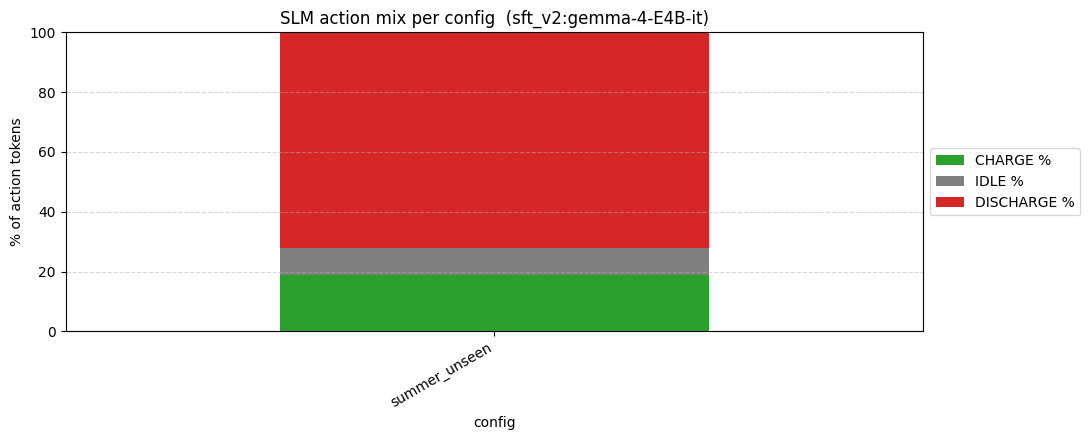

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
summary_actions.plot(kind="bar", stacked=True, ax=ax,
                     color=["#2ca02c", "#7f7f7f", "#d62728"])
ax.set_ylabel("% of action tokens")
ax.set_title(f"SLM action mix per config  ({slm.label})")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

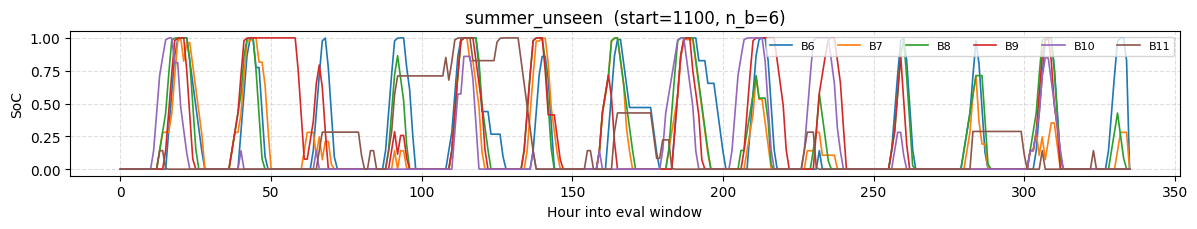

In [19]:
n_cfg = len(CONFIGS)
fig, axes = plt.subplots(nrows=n_cfg, ncols=1, figsize=(12, 2.4*n_cfg), sharex=False)
if n_cfg == 1: axes = [axes]

for ax, cfg in zip(axes, CONFIGS):
    env = cfg["_envs"]["SLM"]
    for i, b in enumerate(env.buildings):
        ax.plot(b.electrical_storage.soc, label=f"B{cfg['buildings'][i]}", linewidth=1.2)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("SoC")
    ax.set_title(f"{cfg['name']}  (start={cfg['start']}, n_b={len(cfg['buildings'])})")
    ax.legend(loc="upper right", ncol=len(cfg["buildings"]), fontsize=8)
    ax.grid(linestyle="--", alpha=0.4)
axes[-1].set_xlabel("Hour into eval window")
plt.tight_layout()
plt.show()

## § 11 — Persist to Drive
Saves the Challenge & ZNE tables, the cross-config summary, the action
distribution, a manifest, and the raw EvalResult `.challenge` / `.zne`
Series so v1-of-nb06 numbers and v2-of-nb06 numbers can later be diffed
off-Colab.

In [20]:
from pathlib import Path

stamp   = time.strftime("%Y%m%d_%H%M%S")
out_dir = Path(f"/content/drive/MyDrive/eclipse-thesis/eval_runs/{ADAPTER_TAG}_v2_{stamp}")
out_dir.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(out_dir / "summary_cross_config.csv")
action_df.to_csv(out_dir / "action_distribution.csv")
summary_actions.to_csv(out_dir / "action_summary.csv")

# Per-config challenge + zne tables
for cfg in CONFIGS:
    chal_df, zne_df = comparison_table(list(cfg["_results"].values()))
    chal_df.to_csv(out_dir / f"challenge_{cfg['name']}.csv")
    zne_df.to_csv(out_dir / f"zne_{cfg['name']}.csv")

manifest = {
    "adapter_path":      ADAPTER_PATH,
    "adapter_tag":       ADAPTER_TAG,
    "model_id":          MODEL_ID,
    "citylearn_version": citylearn.__version__,
    "eval_len":          EVAL_LEN,
    "configs":           [{k: v for k, v in c.items() if not k.startswith('_')}
                          for c in CONFIGS],
    "slm_wall_time_sec": {c["name"]: c["_t_sec"] for c in CONFIGS},
    "fallbacks":         {c["name"]: c["_fb"]    for c in CONFIGS},
}
(out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"✓ Saved to {out_dir}")

✓ Saved to /content/drive/MyDrive/eclipse-thesis/eval_runs/v2_v2_20260511_132233
